# LLM Plan Optimizer — oh-my-openagent soup

Finds the cheapest combination of plans (subscriptions + token APIs) that covers every agent role.

All model data, skill profiles, and plan definitions live in **`models.json`**.  
Agent roles and workload parameters are configured in **Cell 3**.  

**Execution order matters:** the validator in Cell 1 must pass before Cell 2+ can run.

---
```
models.json  ──►  Cell 1: Validate  ──►  Cell 2: Load & index
                                    ──►  Cell 3: Configure agents + budget
                                    ──►  Cell 4: Run optimizer (brute-force)
                                    ──►  Cell 5: Results table
                                    ──►  Cell 6: Token volume reality check
```

## Cell 1 — Validate `models.json`
Asserts model key format, mandatory skills, plan references, pricing fields.  
**Hard-stops on any violation** — fix the JSON and re-run before continuing.

In [1]:
import json, re, sys
from pathlib import Path

MODELS_JSON_PATH = Path("models.json")  # ← change if needed

# ─── Canonical validator ─────────────────

def _print_summary(data: dict, mandatory_skills: set):
    models_def = data["models"]
    plans_def  = data["plans"]
    skills_def = data["skills"]

    print(f"✓  models.json valid — "
          f"{len(models_def)} models · {len(plans_def)} plans · {len(skills_def)} skill dims")
    print(f"   Mandatory skills: {sorted(mandatory_skills)}\n")

    W = 36
    print(f"   {'Model key':<{W}}  {'SWE%':>5}  vibe  hard  agent  notes")
    print(f"   {'─'*W}  {'─'*5}  {'─'*4}  {'─'*4}  {'─'*5}  {'─'*30}")
    for key, m in models_def.items():
        sk    = m.get("skills", {})
        bm    = m.get("benchmarks", {})
        swe   = bm.get("swe_verified", 0)
        swe_s = f"{swe:.0f}%" if swe else "—"
        vibe  = sk.get("vibe", "—")
        hard  = sk.get("hardworkingness", "—")
        agent = sk.get("agentic", "—")
        note  = m.get("notes", "")[:35]
        print(f"   {key:<{W}}  {swe_s:>5}  {vibe:<4}  {hard:<4}  {agent:<5}  {note}")
    print()

    print(f"   {'Plan id':<22}  {'type':<10}  {'$/mo':>6}  {'models'}")
    print(f"   {'─'*22}  {'─'*10}  {'─'*6}  {'─'*40}")
    for plan in plans_def:
        mlist = ", ".join(plan["models"].keys())
        pool  = f" (pool ${plan['credit_pool_usd']})" if plan.get("credit_pool_usd") else ""
        print(f"   {plan['id']:<22}  {plan['type']:<10}  "
              f"${plan['cost_usd_per_month']:>5.2f}  {mlist[:60]}{pool}")
    print()


def validate(path: Path = MODELS_JSON_PATH, silent: bool = False) -> dict:
    raw = Path(path).read_text()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError as e:
        raise AssertionError(f"INVALID JSON in '{path}': {e}")

    skills_def     = data["skills"]
    models_def     = data["models"]
    plans_def      = data["plans"]
    mandatory      = {k for k, v in skills_def.items() if v.get("mandatory")}
    KEY_RE         = re.compile(r"^[a-z0-9_-]+/[a-z0-9_.\-]+$")
    known_keys     = set(models_def.keys())

    # ── 1. No legacy optimizer_id fields ──────────────────────────────────────
    for key, model in models_def.items():
        assert "optimizer_id" not in model, (
            f"LEGACY FIELD 'optimizer_id' found in model '{key}'.\n"
            f"  The model key ('{key}') IS the id now — remove 'optimizer_id'."
        )

    # ── 2. Model key format: provider/name ────────────────────────────────────
    for key in models_def:
        assert KEY_RE.match(key), (
            f"BAD MODEL KEY FORMAT: '{key}'.\n"
            f"  Must be 'provider/name' — lowercase alphanumeric, hyphens, underscores, dots.\n"
            f"  Example: 'anthropic/claude-opus-4-7'"
        )

    # ── 3. Mandatory skills + score range ─────────────────────────────────────
    for key, model in models_def.items():
        skills = model.get("skills", {})
        for s in mandatory:
            assert s in skills, (
                f"MISSING MANDATORY SKILL '{s}' in model '{key}'.\n"
                f"  Model has: {list(skills.keys())}\n"
                f"  Fix: add '{s}': <0–10> to the skills dict."
            )
        for sk, score in skills.items():
            assert sk in skills_def, (
                f"UNKNOWN SKILL '{sk}' in model '{key}'.\n"
                f"  Known skills: {list(skills_def.keys())}\n"
                f"  Fix: add '{sk}' to the top-level skills definition, or remove it."
            )
            assert isinstance(score, (int, float)) and 0 <= score <= 10, (
                f"SKILL SCORE OUT OF RANGE: '{sk}' = {score!r} in model '{key}'.\n"
                f"  Fix: score must be a number in [0, 10]."
            )

    # ── 4. Benchmarks + api_rate present on every model ───────────────────────
    for key, model in models_def.items():
        assert "benchmarks" in model, (
            f"MISSING 'benchmarks' block in model '{key}'.\n"
            f"  Fix: add 'benchmarks': {{'swe_verified': <float>, 'swe_rank': <int>}}"
        )
        assert "swe_verified" in model["benchmarks"], (
            f"MISSING 'benchmarks.swe_verified' in model '{key}'."
        )
        assert "api_rate" in model, (
            f"MISSING 'api_rate' block in model '{key}'.\n"
            f"  Fix: add 'api_rate': {{'input': <$/M>, 'output': <$/M>, 'cached': <$/M>, 'cache_hit_rate': <0-1>}}"
        )
        for field in ("input", "output", "cached", "cache_hit_rate"):
            assert field in model["api_rate"], (
                f"MISSING 'api_rate.{field}' in model '{key}'."
            )

    # ── 5. Plan types ──────────────────────────────────────────────────────────
    valid_types = {"recurrent", "per_token"}
    for plan in plans_def:
        pid = plan.get("id", "<no id>")
        assert "type" in plan, f"PLAN '{pid}' missing 'type' field."
        assert plan["type"] in valid_types, (
            f"INVALID PLAN TYPE '{plan['type']}' in plan '{pid}'.\n"
            f"  Valid: {valid_types}"
        )

    # ── 6. Plan model references resolve ──────────────────────────────────────
    for plan in plans_def:
        pid        = plan.get("id", "<no id>")
        plan_models = plan.get("models", {})
        assert isinstance(plan_models, dict) and len(plan_models) > 0, (
            f"PLAN '{pid}' has no 'models' dict or it is empty."
        )
        for model_key in plan_models:
            assert model_key in known_keys, (
                f"UNKNOWN MODEL REFERENCE '{model_key}' in plan '{pid}'.\n"
                f"  Known models:\n"
                + "\n".join(f"    {k}" for k in sorted(known_keys))
                + f"\n  Fix: correct the key to match exactly one of the above."
            )

    # ── 7. Recurrent plans: request_weight on each model ─────────────────────
    for plan in plans_def:
        pid = plan["id"]
        if plan["type"] == "recurrent":
            for model_key, mdata in plan["models"].items():
                assert "request_weight" in mdata, (
                    f"MISSING 'request_weight' for '{model_key}' in recurrent plan '{pid}'.\n"
                    f"  request_weight = relative token-cost multiplier (gpt-5-4 = 1.0 baseline).\n"
                    f"  Fix: add 'request_weight': <float> to the model entry."
                )
                rw = mdata["request_weight"]
                assert isinstance(rw, (int, float)) and rw > 0, (
                    f"INVALID request_weight {rw!r} for '{model_key}' in plan '{pid}'.\n"
                    f"  Fix: must be a positive number."
                )

    # ── 8. Per-token pure-API plans: pricing on each model ────────────────────
    for plan in plans_def:
        pid = plan["id"]
        if plan["type"] == "per_token" and not plan.get("credit_pool_usd"):
            for model_key, mdata in plan["models"].items():
                for field in ("input_usd_per_m", "output_usd_per_m"):
                    assert field in mdata, (
                        f"MISSING '{field}' for '{model_key}' in per_token plan '{pid}'.\n"
                        f"  Fix: add 'input_usd_per_m' and 'output_usd_per_m' to the model entry."
                    )

    # ── 9. No duplicate plan ids ───────────────────────────────────────────────
    seen: set = set()
    for plan in plans_def:
        pid = plan["id"]
        assert pid not in seen, (
            f"DUPLICATE PLAN ID '{pid}'.\n"
            f"  Fix: each plan must have a unique 'id'."
        )
        seen.add(pid)

    if not silent:
        _print_summary(data, mandatory)

    return data

# ─── Run ──────────────────────────────────────────────────────────────────────
try:
    _raw_data = validate(MODELS_JSON_PATH)
except AssertionError as e:
    print(f"\n{'═'*64}\n  VALIDATION FAILED — fix models.json and re-run\n{'═'*64}\n\n{e}\n")
    raise SystemExit(1)  # blocks further cells in "Run All"


✓  models.json valid — 20 models · 22 plans · 9 skill dims
   Mandatory skills: ['agentic', 'hardworkingness', 'vibe']

   Model key                              SWE%  vibe  hard  agent  notes
   ────────────────────────────────────  ─────  ────  ────  ─────  ──────────────────────────────
   anthropic/claude-opus-4-7               82%  10    9     9      Best overall. Highest SWE-bench (82
   anthropic/claude-opus-4-6               78%  9     8     8      Previous gen Opus. Slightly below 4
   anthropic/claude-sonnet-4-6             77%  8     7     7      Balanced mid-tier. Good for tasks w
   anthropic/claude-haiku-4-5              67%  6     5     4      Fast and cheap. Cuts corners on com
   openai/gpt-5-4                          78%  7     9     8      Workhouse specialist. Best-in-class
   openai/gpt-5-3-codex                    78%  6     10    8      Purpose-built for code. Extremely t
   openai/gpt-5-2                          76%  6     8     7      Older GPT-5 gen. Solid s

## Cell 2 — Load & index `models.json`
Builds typed Python objects from the validated JSON.  
Model keys (`provider/name`) are used throughout — no aliasing.

In [2]:
import itertools, math
from dataclasses import dataclass, field
from typing import Optional

# ─── Data classes ─────────────────────────────────────────────────────────────

@dataclass
class ModelInfo:
    key: str                    # "provider/name" — canonical id
    display_name: str
    skills: dict[str, float]
    swe_verified: float
    swe_rank: int
    swe_pro: Optional[float]
    # API token rates ($/M tokens)
    rate_input: float
    rate_output: float
    rate_cached: float
    cache_hit_rate: float
    notes: str = ""

    def blended_rate(self, input_ratio: float = 0.75) -> float:
        """$/M tokens blended (with cache discount)."""
        eff_inp = (
            self.rate_cached * self.cache_hit_rate
            + self.rate_input * (1 - self.cache_hit_rate)
        ) if self.rate_cached else self.rate_input
        return eff_inp * input_ratio + self.rate_output * (1 - input_ratio)

    def monthly_api_cost(self, tokens_per_day: float, input_ratio: float = 0.75) -> float:
        return self.blended_rate(input_ratio) * tokens_per_day / 1e6 * 30


@dataclass
class PlanInfo:
    id: str
    display_name: str
    provider: str
    plan_type: str              # "recurrent" | "per_token"
    cost_per_month: float
    model_keys: set[str]        # which models this plan unlocks
    # Recurrent: shared token pool
    tokens_per_day: Optional[float] = None
    requests_per_month: Optional[int] = None
    # Per-token (Cursor): $ credit pool
    credit_pool_usd: Optional[float] = None
    # Per-model request weights (recurrent) or per-token pricing (API)
    model_data: dict = field(default_factory=dict)
    notes: str = ""

    @property
    def is_token_api(self) -> bool:
        return self.plan_type == "per_token" and self.credit_pool_usd is None

    @property
    def is_cursor(self) -> bool:
        return self.plan_type == "per_token" and self.credit_pool_usd is not None


# ─── Build indexes ────────────────────────────────────────────────────────────

def _load(data: dict) -> tuple[dict[str, ModelInfo], list[PlanInfo]]:
    models: dict[str, ModelInfo] = {}
    for key, m in data["models"].items():
        bm = m["benchmarks"]
        r  = m["api_rate"]
        models[key] = ModelInfo(
            key          = key,
            display_name = m["display_name"],
            skills       = m.get("skills", {}),
            swe_verified = bm["swe_verified"],
            swe_rank     = bm.get("swe_rank", 99),
            swe_pro      = bm.get("swe_pro"),
            rate_input       = r["input"],
            rate_output      = r["output"],
            rate_cached      = r["cached"],
            cache_hit_rate   = r["cache_hit_rate"],
            notes        = m.get("notes", ""),
        )

    plans: list[PlanInfo] = []
    for p in data["plans"]:
        quota = p.get("quota", {})
        plans.append(PlanInfo(
            id               = p["id"],
            display_name     = p["display_name"],
            provider         = p["provider"],
            plan_type        = p["type"],
            cost_per_month   = p["cost_usd_per_month"],
            model_keys       = set(p["models"].keys()),
            tokens_per_day   = quota.get("tokens_per_day"),
            requests_per_month = quota.get("requests_per_month"),
            credit_pool_usd  = p.get("credit_pool_usd"),
            model_data       = p["models"],
            notes            = p.get("notes", ""),
        ))
    return models, plans


MODELS, PLANS = _load(_raw_data)

print(f"Loaded {len(MODELS)} models, {len(PLANS)} plans.")
print()

# ─── Model reference table ────────────────────────────────────────────────────
print(f"{'Key':<36} {'SWE%':>5}  {'blended $/M':>11}  {'vibe':>4}  {'hard':>4}  {'agt':>3}  Notes")
print("─" * 100)
for key, m in sorted(MODELS.items(), key=lambda x: x[1].swe_rank):
    bl   = m.blended_rate()
    bl_s = "FREE" if bl == 0 else f"${bl:.3f}"
    swe_s = f"{m.swe_verified:.0f}%" if m.swe_verified else "—"
    pro_s = f" [Pro:{m.swe_pro}]" if m.swe_pro else ""
    sk = m.skills
    print(f"{key:<36} {swe_s:>5}  {bl_s:>11}  "
          f"{sk.get('vibe','—'):>4}  {sk.get('hardworkingness','—'):>4}  "
          f"{sk.get('agentic','—'):>3}  {m.notes[:45]}{pro_s}")

Loaded 20 models, 22 plans.

Key                                   SWE%  blended $/M  vibe  hard  agt  Notes
────────────────────────────────────────────────────────────────────────────────────────────────────
anthropic/claude-opus-4-7              82%       $7.975    10     9    9  Best overall. Highest SWE-bench (82%). Except
google/gemini-3-1-pro                  79%       $3.690     8     7    5  Best creative model. Excellent at multimodal,
openai/gpt-5-4                         78%       $4.612     7     9    8  Workhouse specialist. Best-in-class for preci
anthropic/claude-opus-4-6              78%       $7.975     9     8    8  Previous gen Opus. Slightly below 4.7 on benc
openai/gpt-5-3-codex                   78%       $2.018     6    10    8  Purpose-built for code. Extremely thorough, w
anthropic/claude-sonnet-4-6            77%       $4.785     8     7    7  Balanced mid-tier. Good for tasks where Opus 
google/gemini-3-pro                    76%       $3.690     7     6   

## Cell 3 — Configure agents & budget
Edit this cell to change the agent soup, workload, or budget.

**`model_ranking`** — ordered list of `provider/name` keys, best preferred first.  
**`min_swe`** — minimum SWE-bench Verified % acceptable for this role.  
**`skill_weights`** — optional: weight model selection by skill scores (in addition to SWE rank).  
A score of `0` on a mandatory skill doesn't disqualify — use `min_swe` for hard cutoffs.

In [3]:
from dataclasses import dataclass
from typing import Optional

# ─── Budget & workload ────────────────────────────────────────────────────────

BUDGET_USD          = 60.0     # monthly budget
TOKENS_PER_DAY      = 50_000_000  # total daily tokens across all agents
INPUT_RATIO         = 0.75     # fraction of tokens that are input (rest = output)
MAX_PLANS_IN_COMBO  = 4        # brute-force up to this many plans per combo
TOP_N               = 15       # how many results to show

# ─── Agent definitions ────────────────────────────────────────────────────────
# token_weight: fraction of TOKENS_PER_DAY consumed by this agent (must sum to 1.0)
# model_ranking: provider/name keys in preference order (best first, fallbacks after)
# min_swe: minimum SWE-bench Verified % — combo is infeasible if no model meets this

@dataclass
class Agent:
    key: str
    name: str
    role: str
    token_weight: float
    model_ranking: list[str]
    min_swe: float = 0.0

AGENTS: list[Agent] = [
    Agent(
        key="sisyphus", name="Sisyphus", role="Orchestrator — planning, delegation",
        token_weight=0.30,
        model_ranking=[
            "anthropic/claude-opus-4-7",
            "anthropic/claude-opus-4-6",
            "moonshot/kimi-k2-6",
            "moonshot/kimi-k2-5",
            "zai/glm-5-1",
        ],
        min_swe=70.0,
    ),
    Agent(
        key="prometheus", name="Prometheus", role="Strategic planner",
        token_weight=0.10,
        model_ranking=[
            "anthropic/claude-opus-4-7",
            "anthropic/claude-opus-4-6",
            "moonshot/kimi-k2-6",
            "moonshot/kimi-k2-5",
            "zai/glm-5-1",
            "zai/glm-5",
        ],
        min_swe=70.0,
    ),
    Agent(
        key="hephaestus", name="Hephaestus", role="Deep executor — hard logic, architecture",
        token_weight=0.30,
        model_ranking=[
            "openai/gpt-5-4",
            "openai/gpt-5-3-codex",
            "zai/glm-5-1",
            "openai/gpt-5-2",
            "google/gemini-3-1-pro",
        ],
        min_swe=75.0,
    ),
    Agent(
        key="creative", name="Creative", role="Generative / creative coding",
        token_weight=0.15,
        model_ranking=[
            "google/gemini-3-1-pro",
            "google/gemini-3-pro",
            "google/gemini-3-flash",
            "anthropic/claude-sonnet-4-6",
        ],
        min_swe=60.0,
    ),
    Agent(
        key="speed", name="Speed", role="Fast lightweight tasks",
        token_weight=0.15,
        model_ranking=[
            "minimax/minimax-m2-5",
            "minimax/minimax-m2-7",
            "zai/glm-4-7",
            "openai/gpt-5-4-mini",
            "google/gemini-3-flash",
        ],
        min_swe=50.0,
    ),
]

# ─── Validate agent model refs ────────────────────────────────────────────────
for ag in AGENTS:
    for mkey in ag.model_ranking:
        assert mkey in MODELS, (
            f"Agent '{ag.key}' references unknown model '{mkey}'.\n"
            f"  Known: {sorted(MODELS.keys())}"
        )

total_weight = sum(ag.token_weight for ag in AGENTS)
assert abs(total_weight - 1.0) < 1e-6, (
    f"Agent token_weights must sum to 1.0, got {total_weight:.4f}.")

print(f"Budget: ${BUDGET_USD}/mo   |   "
      f"Tokens/day: {TOKENS_PER_DAY/1e6:.1f}M   |   "
      f"Max plans/combo: {MAX_PLANS_IN_COMBO}")
print()
print(f"{'Agent':<12} {'Role':<38} {'Weight':>7}  {'Tok/day':>10}  {'min SWE':>7}")
print("─" * 80)
for ag in AGENTS:
    print(f"{ag.name:<12} {ag.role:<38} {ag.token_weight*100:>6.0f}%  "
          f"{TOKENS_PER_DAY*ag.token_weight/1e6:>9.1f}M  {ag.min_swe:>6.0f}%")

Budget: $60.0/mo   |   Tokens/day: 50.0M   |   Max plans/combo: 4

Agent        Role                                    Weight     Tok/day  min SWE
────────────────────────────────────────────────────────────────────────────────
Sisyphus     Orchestrator — planning, delegation        30%       15.0M      70%
Prometheus   Strategic planner                          10%        5.0M      70%
Hephaestus   Deep executor — hard logic, architecture     30%       15.0M      75%
Creative     Generative / creative coding               15%        7.5M      60%
Speed        Fast lightweight tasks                     15%        7.5M      50%


## Cell 4 — Optimizer

Brute-forces all plan combinations up to `MAX_PLANS_IN_COMBO`.  
For each feasible combo it computes the exact monthly cost:  
- Subscription base cost  
- Token pool overflow (charged at cheapest model API rate in that plan)  
- Cursor credit pool burn → overage  
- Direct API token cost  

Results are deduplicated by effective agent assignment and sorted by quality-per-dollar score.

In [4]:
# ─── Cost computation ─────────────────────────────────────────────────────────

def compute_combo(
    combo: tuple[PlanInfo, ...],
    agents: list[Agent],
    tokens_per_day: float,
    input_ratio: float,
) -> tuple[float, dict, bool]:
    """
    Returns (monthly_cost, breakdown, is_feasible).

    Assignment strategy (packing problem):
    1. For each agent, walk its model_ranking and pick the first model
       available in the combo that meets min_swe.
    2. Models from recurrent plans → shared token pool; overflow at API rate.
    3. Models from Cursor plans   → credit pool consumed at API rates; overage charged.
    4. Models from API plans      → direct per-token billing.
    """
    sub_plans    = [p for p in combo if p.plan_type == "recurrent"]
    cursor_plans = [p for p in combo if p.is_cursor]
    api_plans    = [p for p in combo if p.is_token_api]

    # Model → first plan that unlocks it (priority: sub > cursor > api)
    unlock_sub:    dict[str, PlanInfo] = {}
    unlock_cursor: dict[str, PlanInfo] = {}
    unlock_api:    dict[str, PlanInfo] = {}
    for p in sub_plans:
        for mk in p.model_keys:
            unlock_sub.setdefault(mk, p)
    for p in cursor_plans:
        for mk in p.model_keys:
            unlock_cursor.setdefault(mk, p)
    for p in api_plans:
        for mk in p.model_keys:
            unlock_api.setdefault(mk, p)

    all_available = set(unlock_sub) | set(unlock_cursor) | set(unlock_api)

    # Assign best model to each agent
    assignments: dict[str, dict] = {}
    for ag in agents:
        chosen, source = None, None
        for mkey in ag.model_ranking:
            if mkey not in all_available:
                continue
            m = MODELS[mkey]
            if ag.min_swe > 0 and m.swe_verified < ag.min_swe and m.swe_verified > 0:
                continue
            chosen = m
            source = ("sub"    if mkey in unlock_sub    else
                      "cursor" if mkey in unlock_cursor else "api")
            break
        if chosen is None:
            return float("inf"), {}, False
        assignments[ag.key] = {
            "agent":      ag,
            "model":      chosen,
            "source":     source,
            "tok_day":    tokens_per_day * ag.token_weight,
        }

    # ── Subscription base ─────────────────────────────────────────────────────
    sub_base = sum(p.cost_per_month for p in sub_plans)

    # ── Token pool overflow ───────────────────────────────────────────────────
    plan_tok_demand: dict[str, float] = {}  # plan.id → daily tokens demanded
    for asgn in assignments.values():
        if asgn["source"] != "sub":
            continue
        plan = unlock_sub[asgn["model"].key]
        plan_tok_demand[plan.id] = plan_tok_demand.get(plan.id, 0) + asgn["tok_day"]

    overflow_cost = 0.0
    for plan in sub_plans:
        if plan.tokens_per_day is None:
            continue  # no explicit pool (e.g. request-based plans — treat as adequate)
        monthly_pool   = plan.tokens_per_day * 30
        monthly_demand = plan_tok_demand.get(plan.id, 0) * 30
        if monthly_demand > monthly_pool:
            overflow = monthly_demand - monthly_pool
            # Price overflow at cheapest API rate among models in this plan
            rates = [
                MODELS[mk].blended_rate(input_ratio)
                for mk in plan.model_keys
                if mk in MODELS and MODELS[mk].blended_rate(input_ratio) > 0
            ]
            if rates:
                overflow_cost += min(rates) * overflow / 1e6

    # ── Cursor credit pool ────────────────────────────────────────────────────
    cursor_extra = 0.0
    if cursor_plans:
        best_cursor = max(cursor_plans, key=lambda p: p.credit_pool_usd)
        cursor_burn = 0.0
        for asgn in assignments.values():
            if asgn["source"] != "cursor":
                continue
            m = asgn["model"]
            cursor_burn += m.blended_rate(input_ratio) * asgn["tok_day"] / 1e6 * 30
        if cursor_burn > best_cursor.credit_pool_usd:
            cursor_extra = cursor_burn - best_cursor.credit_pool_usd

    # ── Direct API cost ───────────────────────────────────────────────────────
    api_cost = 0.0
    for asgn in assignments.values():
        if asgn["source"] != "api":
            continue
        api_cost += asgn["model"].monthly_api_cost(asgn["tok_day"], input_ratio)

    cursor_base = sum(p.cost_per_month for p in cursor_plans)
    total = sub_base + cursor_base + overflow_cost + cursor_extra + api_cost

    breakdown = {
        "sub_base":     sub_base,
        "cursor_base":  cursor_base,
        "overflow":     overflow_cost,
        "cursor_extra": cursor_extra,
        "api_cost":     api_cost,
        "total":        total,
        "plans":        [p.id for p in combo],
        "assignments":  assignments,
    }
    return total, breakdown, True


def quality_score(assignments: dict) -> float:
    """Token-weight-averaged SWE-bench Verified score across all agents."""
    total_w = sum(a["agent"].token_weight for a in assignments.values())
    return sum(
        a["agent"].token_weight * a["model"].swe_verified
        for a in assignments.values()
    ) / total_w


def combo_score(cost: float, breakdown: dict, budget: float) -> float:
    """Quality / cost efficiency. Penalises over-budget combos."""
    q = quality_score(breakdown["assignments"]) / 100
    efficiency = min(1.0, budget / cost) ** 1.5 if cost > 0 else 0
    return q * efficiency


# ─── Brute-force optimizer ────────────────────────────────────────────────────

def optimize(
    plans: list[PlanInfo],
    agents: list[Agent],
    tokens_per_day: float,
    budget: float,
    input_ratio: float,
    max_plans: int,
    top_n: int,
) -> list[dict]:
    n = len(plans)
    total_combos = sum(math.comb(n, r) for r in range(1, max_plans + 1))
    print(f"Searching {total_combos:,} combinations (up to {max_plans} plans)…")

    results = []
    for size in range(1, max_plans + 1):
        for combo in itertools.combinations(plans, size):
            cost, breakdown, ok = compute_combo(combo, agents, tokens_per_day, input_ratio)
            if not ok:
                continue
            score = combo_score(cost, breakdown, budget)
            results.append({
                "cost":     cost,
                "score":    score,
                "quality":  quality_score(breakdown["assignments"]),
                "n_plans":  size,
                "within":   cost <= budget,
                "breakdown":breakdown,
            })

    # Deduplicate: combos that produce identical agent→model assignments
    # are equivalent — keep the cheapest / fewest-plans version.
    seen: dict[frozenset, int] = {}
    deduped: list[dict] = []
    for r in results:
        fp = frozenset(
            (k, a["model"].key, a["source"])
            for k, a in r["breakdown"]["assignments"].items()
        )
        if fp in seen:
            idx = seen[fp]
            ex  = deduped[idx]
            if r["cost"] < ex["cost"] or (
                r["cost"] == ex["cost"] and r["n_plans"] < ex["n_plans"]
            ):
                deduped[idx] = r
        else:
            seen[fp] = len(deduped)
            deduped.append(r)

    deduped.sort(key=lambda r: (-r["score"], r["cost"]))
    in_budget = sum(1 for r in deduped if r["within"])
    print(f"Done. {len(deduped):,} unique feasible solutions "
          f"({in_budget} within ${budget:.0f} budget).")
    return deduped[:top_n]


# ─── Run ──────────────────────────────────────────────────────────────────────
RESULTS = optimize(
    plans      = PLANS,
    agents     = AGENTS,
    tokens_per_day = TOKENS_PER_DAY,
    budget     = BUDGET_USD,
    input_ratio = INPUT_RATIO,
    max_plans  = MAX_PLANS_IN_COMBO,
    top_n      = TOP_N,
)

Searching 9,108 combinations (up to 4 plans)…
Done. 112 unique feasible solutions (0 within $60 budget).


## Cell 5 — Results table
Ranked by quality-per-dollar score. ✓ = within budget.

In [5]:
BAR = "─" * 72

def print_results(results: list[dict], budget: float, tok: float):
    if not results:
        print("No feasible combinations found.")
        return

    print(f"{'═'*72}")
    print(f"  TOP {len(results)} COMBINATIONS — "
          f"ranked by quality-per-dollar score")
    print(f"  Budget ${budget}/mo · {tok/1e6:.0f}M tok/day · "
          f"{INPUT_RATIO*100:.0f}% input")
    print(f"{'═'*72}")

    for i, r in enumerate(results, 1):
        bd   = r["breakdown"]
        mark = "✓" if r["within"] else "✗"
        print(f"\n  [{i:02d}] {mark} ${r['cost']:>9,.2f}/mo  "
              f"score={r['score']:.4f}  quality={r['quality']:.1f}%  "
              f"plans={r['n_plans']}")
        print(f"       Plans: {', '.join(bd['plans'])}")

        # Cost breakdown
        parts = []
        if bd["sub_base"]:     parts.append(f"subs ${bd['sub_base']:.2f}")
        if bd["cursor_base"]:  parts.append(f"cursor ${bd['cursor_base']:.2f}")
        if bd["overflow"]:     parts.append(f"overflow ${bd['overflow']:.2f}")
        if bd["cursor_extra"]: parts.append(f"cursor-overage ${bd['cursor_extra']:.2f}")
        if bd["api_cost"]:     parts.append(f"api ${bd['api_cost']:.2f}")
        print(f"       Cost:  {' + '.join(parts) or '$0'}")

        print(f"       {BAR[:60]}")
        print(f"       {'Agent':<12} {'Model (key)':<38} {'SWE%':>5}  "
              f"{'src':>3}  {'skills: v/h/a':>14}  {'$/mo':>12}")
        print(f"       {BAR[:60]}")
        for ak, a in bd["assignments"].items():
            m    = a["model"]
            ag   = a["agent"]
            src  = a["source"]
            sk   = m.skills
            skill_s = (f"{sk.get('vibe','?')}/"
                       f"{sk.get('hardworkingness','?')}/"
                       f"{sk.get('agentic','?')}")
            if src == "api":
                cost_s = f"${m.monthly_api_cost(a['tok_day'], INPUT_RATIO):>9,.2f}"
            elif src == "cursor":
                burn = m.blended_rate(INPUT_RATIO) * a['tok_day'] / 1e6 * 30
                cost_s = f"${burn:>9,.2f} (pool)"
            else:
                cost_s = "     sub quota"
            print(f"       {ag.name:<12} {m.key:<38} {m.swe_verified:>4.0f}%  "
                  f"{src:>3}  {skill_s:>14}  {cost_s}")
        print(f"       {BAR[:60]}")

    # Winner / closest
    within = [r for r in results if r["within"]]
    print(f"\n{'═'*72}")
    if within:
        w  = within[0]
        bd = w["breakdown"]
        print(f"  ✓ WINNER (${w['cost']:,.2f}/mo, {w['quality']:.1f}% avg SWE)")
        print(f"  Plans: {', '.join(bd['plans'])}")
        print(f"  Stack:")
        for ak, a in bd["assignments"].items():
            extras = []
            if a["model"].key == "moonshot/kimi-k2-6":
                extras.append("← SWE Pro #1 (58.6), 300 sub-agents")
            if a["model"].key == "zai/glm-5-1":
                extras.append("← GPT-5.4 level, SWE Pro 58.4")
            extra_s = "  " + extras[0] if extras else ""
            print(f"    {a['agent'].name:<12} → {a['model'].display_name}{extra_s}")
    else:
        cheapest = sorted(results, key=lambda r: r["cost"])[0]
        print(f"  ✗ NO combo fits ${budget:.0f}/mo at {tok/1e6:.0f}M tok/day")
        print(f"  Cheapest feasible: ${cheapest['cost']:,.2f}/mo "
              f"({cheapest['cost']/budget:.1f}× over budget)")
        print(f"  Plans: {', '.join(cheapest['breakdown']['plans'])}")
    print()


print_results(RESULTS, BUDGET_USD, TOKENS_PER_DAY)

════════════════════════════════════════════════════════════════════════
  TOP 15 COMBINATIONS — ranked by quality-per-dollar score
  Budget $60.0/mo · 50M tok/day · 75% input
════════════════════════════════════════════════════════════════════════

  [01] ✗ $   100.79/mo  score=0.3552  quality=77.3%  plans=2
       Plans: copilot-pro, api-minimax
       Cost:  subs $10.00 + api $90.79
       ────────────────────────────────────────────────────────────
       Agent        Model (key)                             SWE%  src   skills: v/h/a          $/mo
       ────────────────────────────────────────────────────────────
       Sisyphus     anthropic/claude-opus-4-6                78%  sub           9/8/8       sub quota
       Prometheus   anthropic/claude-opus-4-6                78%  sub           9/8/8       sub quota
       Hephaestus   openai/gpt-5-4                           78%  sub           7/9/8       sub quota
       Creative     google/gemini-3-pro                      76%  sub

## Cell 6 — Token volume reality check
Shows per-agent API rates and the maximum daily tokens affordable at budget.

In [6]:
if not RESULTS:
    print("No results to analyse.")
else:
    # Use cheapest combo as the reference stack
    cheapest = sorted(RESULTS, key=lambda r: r["cost"])[0]
    bd       = cheapest["breakdown"]

    print(f"{'═'*72}")
    print(f"  TOKEN VOLUME REALITY CHECK")
    print(f"  Reference stack: {', '.join(bd['plans'])}")
    print(f"{'═'*72}")
    print(f"  Target workload: {TOKENS_PER_DAY/1e6:.0f}M tok/day = "
          f"{TOKENS_PER_DAY*30/1e6:.0f}M tok/month")
    print(f"  Budget:          ${BUDGET_USD}/mo")
    print()

    # Per-agent blended API rate (regardless of actual source in cheapest combo)
    print(f"  {'Agent':<12} {'Model':<28} {'Blended $/M':>12}  "
          f"{'Weight':>7}  {'Weighted $/M':>13}")
    print(f"  {'─'*12} {'─'*28} {'─'*12}  {'─'*7}  {'─'*13}")

    total_weighted_rate = 0.0
    for ak, a in bd["assignments"].items():
        m    = a["model"]
        frac = a["agent"].token_weight
        bl   = m.blended_rate(INPUT_RATIO)
        w_bl = bl * frac
        total_weighted_rate += w_bl
        bl_s  = "FREE" if bl == 0 else f"${bl:.4f}"
        w_s   = "FREE" if w_bl == 0 else f"${w_bl:.4f}"
        print(f"  {a['agent'].name:<12} {m.display_name:<28} {bl_s:>12}  "
              f"{frac*100:>6.0f}%  {w_s:>13}")

    print(f"  {'─'*72}")
    print(f"  {'Weighted blended rate':<42} ${total_weighted_rate:.4f}/M tokens")
    print()

    if total_weighted_rate > 0:
        # Monthly cost = rate * tok/day / 1e6 * 30
        actual_monthly = total_weighted_rate * TOKENS_PER_DAY / 1e6 * 30
        affordable_daily = BUDGET_USD / (total_weighted_rate * 30 / 1e6)
        coverage_pct     = affordable_daily / TOKENS_PER_DAY * 100

        print(f"  Cost at {TOKENS_PER_DAY/1e6:.0f}M tok/day:    ${actual_monthly:>10,.2f}/mo")
        print(f"  Affordable at ${BUDGET_USD}/mo:  {affordable_daily/1e6:>8.2f}M tok/day "
              f"({coverage_pct:.1f}% of target)")

        if coverage_pct < 100:
            scale_needed = TOKENS_PER_DAY / affordable_daily
            print(f"  Budget needed for target:   ${BUDGET_USD * scale_needed:>10,.2f}/mo "
                  f"({scale_needed:.1f}× current budget)")
    else:
        print(f"  All agents on free models — effectively $0/mo for API costs.")

    print()
    print(f"  Skill profile of cheapest stack (v=vibe / h=hardwork / a=agentic):")
    for ak, a in bd["assignments"].items():
        m  = a["model"]
        sk = m.skills
        all_s = "  ".join(
            f"{name[:4]}={val}"
            for name, val in sk.items()
        )
        print(f"    {a['agent'].name:<12} {m.display_name:<28}  {all_s}")

════════════════════════════════════════════════════════════════════════
  TOKEN VOLUME REALITY CHECK
  Reference stack: copilot-pro, api-minimax
════════════════════════════════════════════════════════════════════════
  Target workload: 50M tok/day = 1500M tok/month
  Budget:          $60.0/mo

  Agent        Model                         Blended $/M   Weight   Weighted $/M
  ──────────── ──────────────────────────── ────────────  ───────  ─────────────
  Sisyphus     Claude Opus 4.6                   $7.9750      30%        $2.3925
  Prometheus   Claude Opus 4.6                   $7.9750      10%        $0.7975
  Hephaestus   GPT-5.4                           $4.6125      30%        $1.3837
  Creative     Gemini 3 Pro                      $3.6900      15%        $0.5535
  Speed        MiniMax-M2.5                      $0.4035      15%        $0.0605
  ────────────────────────────────────────────────────────────────────────
  Weighted blended rate                      $5.1878/M tokens

## Cell 7 — Skill matrix heatmap *(optional)*
Visual grid of every model's skill scores.

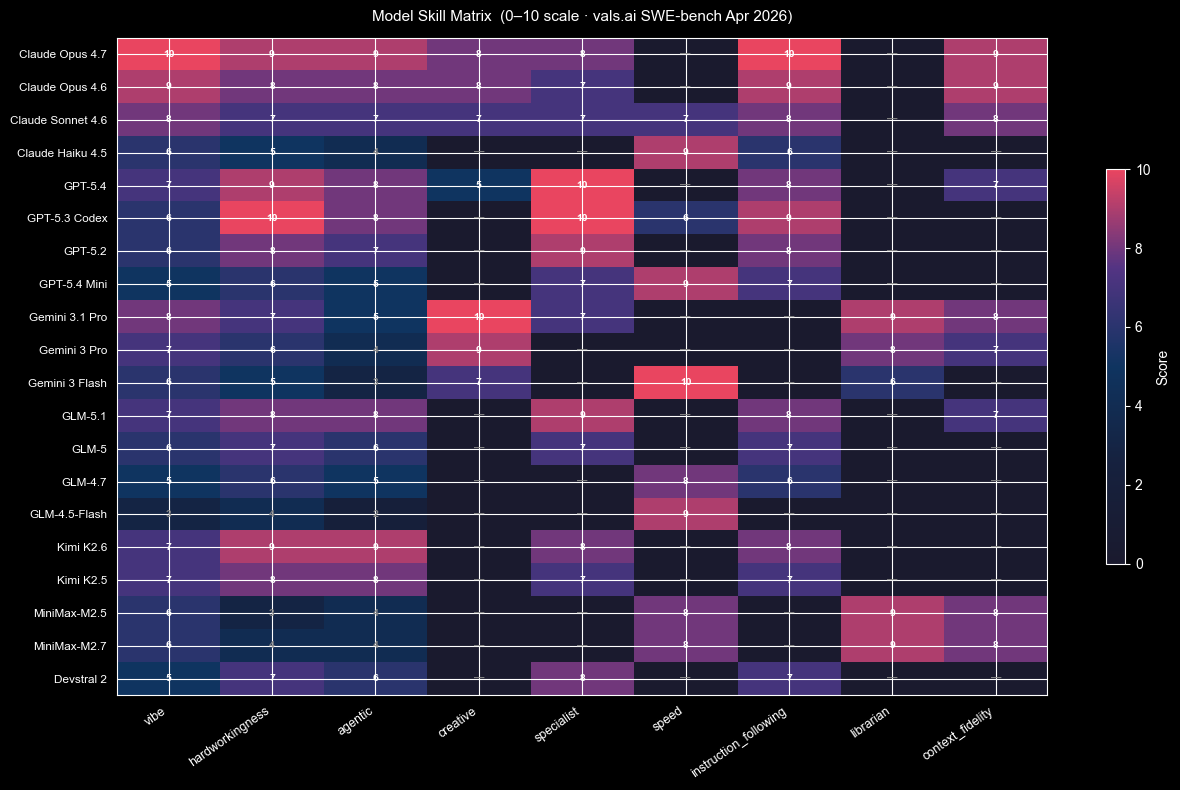

Saved skill_matrix.png


In [7]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
except ImportError:
    print("matplotlib not installed — run: pip install matplotlib")
    raise

skill_names = list(_raw_data["skills"].keys())
model_labels = [m.display_name for m in MODELS.values()]
model_keys   = list(MODELS.keys())

matrix = np.zeros((len(model_keys), len(skill_names)))
for i, mk in enumerate(model_keys):
    m = MODELS[mk]
    for j, sk in enumerate(skill_names):
        matrix[i, j] = m.skills.get(sk, 0)

fig, ax = plt.subplots(figsize=(13, 8))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "skill", ["#1a1a2e", "#16213e", "#0f3460", "#533483", "#e94560"], N=256
)
im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=10, aspect="auto")

ax.set_xticks(range(len(skill_names)))
ax.set_xticklabels(skill_names, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels, fontsize=8.5)

for i in range(len(model_keys)):
    for j in range(len(skill_names)):
        val = matrix[i, j]
        ax.text(j, i, f"{val:.0f}" if val else "—",
                ha="center", va="center",
                color="white" if val >= 5 else "#888", fontsize=7.5, fontweight="bold")

ax.set_title("Model Skill Matrix  (0–10 scale · vals.ai SWE-bench Apr 2026)",
             fontsize=11, pad=12)
plt.colorbar(im, ax=ax, label="Score", shrink=0.6)
plt.tight_layout()
plt.savefig("skill_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved skill_matrix.png")